In [2]:
import numpy as np
import pandas as pd

In [8]:
df= pd.read_csv("../data/zomato.csv")
print(df.head())

                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          Yes        Yes  4.1/5    775    080 42297555\r\n+91 9743772233   
1          Yes         No  4.1/5  

In [11]:
print(df.describe())


              votes
count  51717.000000
mean     283.697527
std      803.838853
min        0.000000
25%        7.000000
50%       41.000000
75%      198.000000
max    16832.000000


In [12]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [13]:
df_copy=df.copy()

In [14]:
cols_to_drop = ['url', 'address', 'phone', 'menu_item', 'reviews_list']
df_copy.drop(columns=[col for col in cols_to_drop if col in df_copy.columns], inplace=True, errors='ignore')

In [15]:
def parse_rating(val):
    if pd.isna(val) or val in ['NEW', '-']:
        return np.nan
    return float(str(val).split('/')[0].strip())

df_copy['rate'] = df_copy['rate'].apply(parse_rating)
# Impute missing ratings with the overall median
df_copy['rate'] = df_copy['rate'].fillna(df_copy['rate'].median())

In [16]:
cost_col = 'approx_cost(for two people)'
if cost_col in df_copy.columns:
    df_copy[cost_col] = df_copy[cost_col].astype(str).str.replace(',', '')
    df_copy[cost_col] = pd.to_numeric(df_copy[cost_col], errors='coerce')
    # Safe fallback imputation based on restaurant type median
    df_copy[cost_col] = df_copy.groupby('rest_type')[cost_col].transform(lambda x: x.fillna(x.median()))

In [17]:
df_copy['location'] = df_copy['location'].fillna('Unknown').astype(str).str.strip()
df_copy['rest_type'] = df_copy['rest_type'].fillna('Quick Bites').astype(str).str.strip()

In [18]:
print("Data Pipeline Executed on df_copy!")
print(df_copy[['rate', cost_col]].info())

Data Pipeline Executed on df_copy!
<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   rate                         51717 non-null  float64
 1   approx_cost(for two people)  51490 non-null  float64
dtypes: float64(2)
memory usage: 808.2 KB
None


In [19]:
print(df_copy.info())

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51717 non-null  str    
 1   online_order                 51717 non-null  str    
 2   book_table                   51717 non-null  str    
 3   rate                         51717 non-null  float64
 4   votes                        51717 non-null  int64  
 5   location                     51717 non-null  str    
 6   rest_type                    51717 non-null  str    
 7   dish_liked                   23639 non-null  str    
 8   cuisines                     51672 non-null  str    
 9   approx_cost(for two people)  51490 non-null  float64
 10  listed_in(type)              51717 non-null  str    
 11  listed_in(city)              51717 non-null  str    
dtypes: float64(2), int64(1), str(9)
memory usage: 10.6 MB
None


In [20]:
cost_col = 'approx_cost(for two people)'

global_median_cost = df_copy[cost_col].median()
df_copy[cost_col] = df_copy[cost_col].fillna(global_median_cost)

print("Verifying the patch:")
print(f"Total entries in DataFrame: {len(df_copy)}")
print(f"Total non-null values in cost: {df_copy[cost_col].notna().sum()}")

Verifying the patch:
Total entries in DataFrame: 51717
Total non-null values in cost: 51717


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

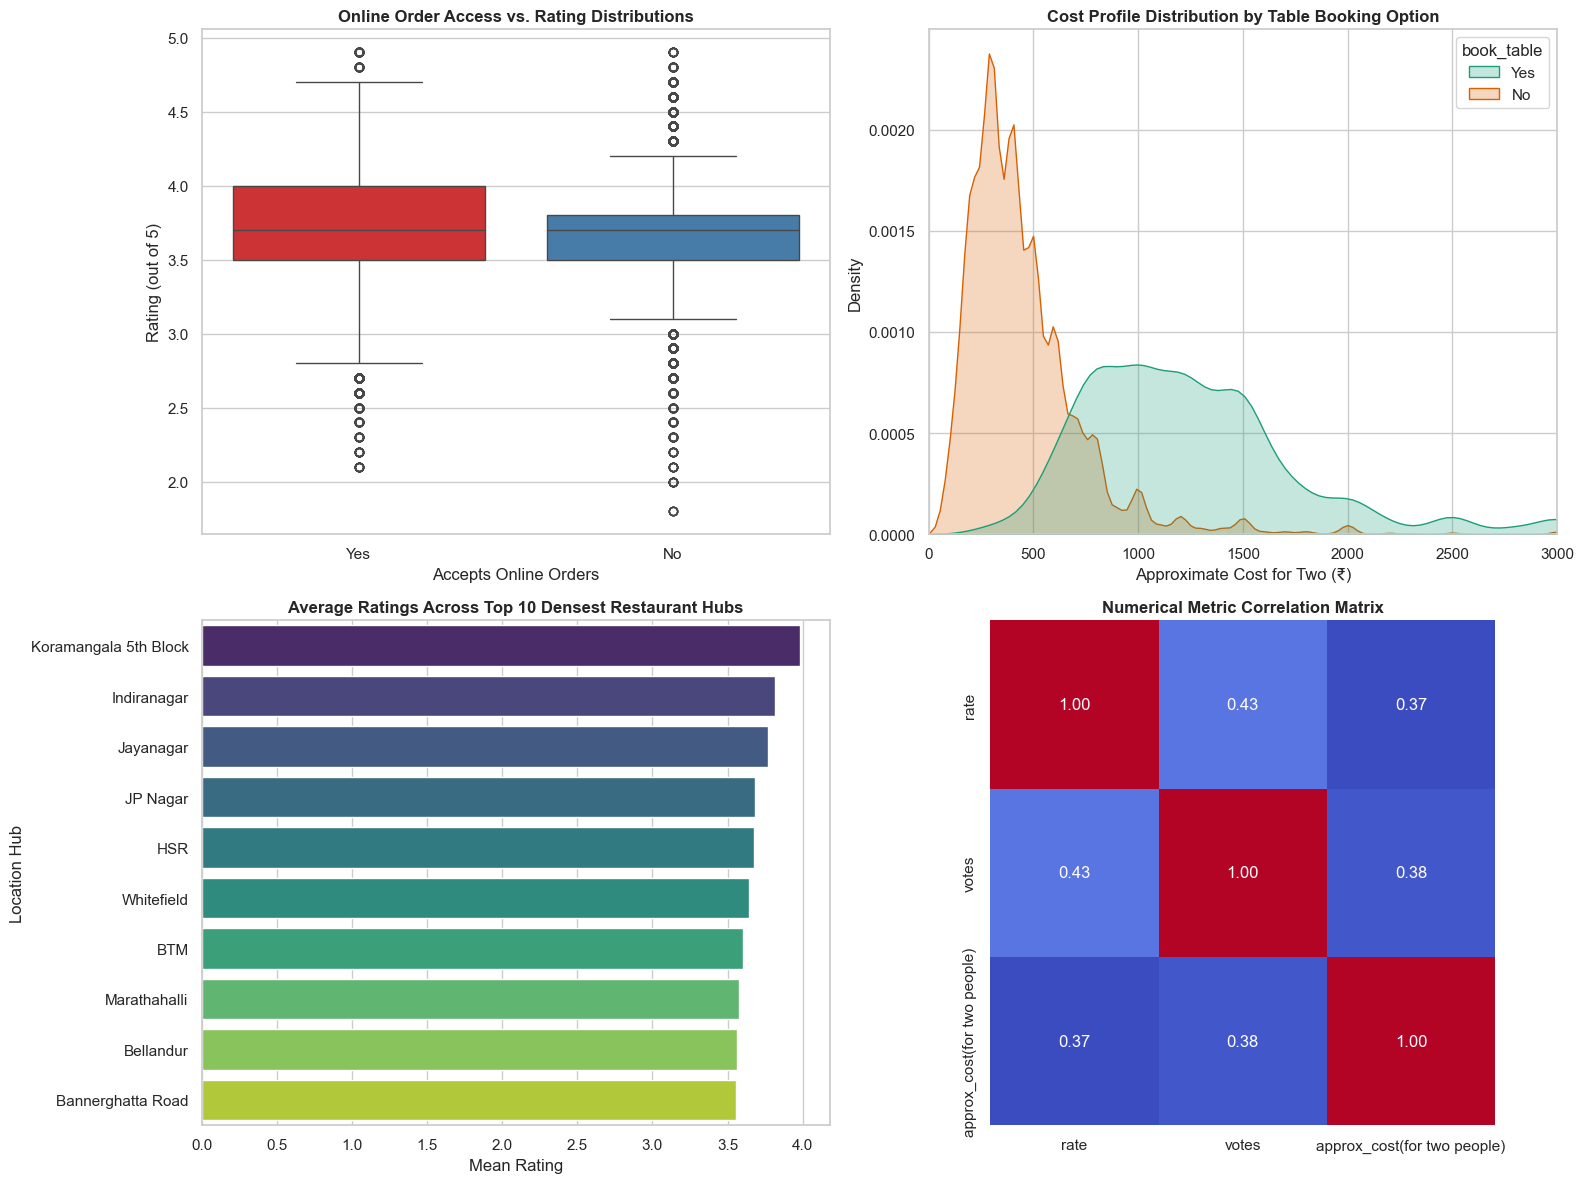

In [27]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
#boxplot
sns.boxplot(ax=axes[0, 0], data=df_copy, x='online_order', y='rate', hue='online_order', palette='Set1', legend=False)
axes[0, 0].set_title('Online Order Access vs. Rating Distributions', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Accepts Online Orders')
axes[0, 0].set_ylabel('Rating (out of 5)')
#kdeplot
cost_col = 'approx_cost(for two people)'
sns.kdeplot(ax=axes[0, 1], data=df_copy, x=cost_col, hue='book_table', fill=True, common_norm=False, palette='Dark2')
axes[0, 1].set_title('Cost Profile Distribution by Table Booking Option', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Approximate Cost for Two (₹)')
axes[0, 1].set_xlim(0, 3000)
#barplot 
top_locations = df_copy['location'].value_counts().head(10).index
location_summary = df_copy[df_copy['location'].isin(top_locations)].groupby('location')['rate'].mean().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[1, 0], data=location_summary, x='rate', y='location', hue='location', palette='viridis', legend=False)
axes[1, 0].set_title('Average Ratings Across Top 10 Densest Restaurant Hubs', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Mean Rating')
axes[1, 0].set_ylabel('Location Hub')
#correlation heatmap
corr_matrix = df_copy[['rate', 'votes', cost_col]].corr()
sns.heatmap(ax=axes[1, 1], data=corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar=False)
axes[1, 1].set_title('Numerical Metric Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [28]:
df_copy.to_csv('../data/zomato_cleaned_dataset.csv', index=False)
print("Clean dataset successfully created and exported to your data folder!")

Clean dataset successfully created and exported to your data folder!
